# 01 - EDA: Amazon Product Reviews (Fake Review Detection)

**Dataset**: real Amazon product reviews (McAuley-style export from Kaggle), one row per review, one product per `productASIN`.

In [17]:
import pandas as pd

df = pd.read_csv('../data/raw/reviews.csv', encoding='utf-8')
print(df.shape)
print(df.columns.tolist())
df.head()

(6327, 23)
['s.no', 'helpfulVoteCount', 'images/0', 'images/1', 'images/2', 'images/3', 'images/4', 'images/5', 'images/6', 'images/7', 'productASIN', 'productVariant', 'rating', 'reviewID', 'reviewMetadata', 'reviewPosition', 'reviewText', 'reviewTitle', 'reviewURL', 'verifiedPurchase', 'videos/0', 'cleaned_review_text', 'sentiment_score']


,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,...,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321
3,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",3,This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type...,0.307949
4,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",4,With these three polo shirts I was very satisf...,Pocket Polos Looks Good,https://www.amazon.com/review/RP17IW9ZKENDZ,False,NaN,three polo shirt satisfied quality material go...,0.250000


## Cleaning
- Drop exact duplicate review text
- Drop rows with no text or no rating
- Extract a real datetime from `reviewMetadata` (format: "Reviewed in the United States on <Month DD, YYYY>")
- Fix mojibake in `reviewText` (emoji/punctuation got double-encoded when the CSV was exported)
- Keep `productASIN` as the true product identifier (there is no equivalent of "app version" here — each review belongs to one product)

In [18]:
import re

# dropping duplicates (same review text)
df = df.drop_duplicates(subset=['reviewText'])

# drop rows with no text or no rating 
df = df.dropna(subset=['reviewText', 'rating'])

# Fix common mojibake from a mis-decoded UTF-8 export (e.g. emoji/punctuation)
def fix_mojibake(t):
    t = str(t)
    try:
        return t.encode('cp1252').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        return t

df['reviewText'] = df['reviewText'].apply(fix_mojibake)

# Extract the review date out of the free-text reviewMetadata field
def extract_date(meta):
    m = re.search(r'on (.+)$', str(meta))
    return m.group(1) if m else None

df['at'] = pd.to_datetime(df['reviewMetadata'].apply(extract_date), errors='coerce') #errors='coerce' will set invalid parsing to NaT

# Basic text cleaning 
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-z0-9\s.,!?\'"-]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t 

df['content_clean'] = df['reviewText'].apply(clean_text)

# Normalize verifiedPurchase to a clean boolean
df['verifiedPurchase'] = df['verifiedPurchase'].astype(str).str.strip().str.lower().map({'true': True, 'false': False})

print(df.shape)
print('Rows with unresolved date:', df['at'].isna().sum())

(6232, 25)
Rows with unresolved date: 0


In [20]:
# check for any remaining mojibake artifacts in the review text
sample = df['reviewText'].astype(str)
suspicious = sample[sample.str.contains('Ã|â€', regex=True, na=False)]
print(f"Reviews still containing mojibake artifacts: {len(suspicious)}")
if len(suspicious) > 0:
    print(suspicious.iloc[0][:200])

Reviews still containing mojibake artifacts: 0


***Checking for missing values***  

In [ ]:
print(df.isna().mean().sort_values(ascending=False) * 100)

images/7               99.919769
images/6               99.887677
images/5               99.775353
images/4               99.582798
videos/0               99.454429
images/3               99.229782
images/2               98.443517
images/1               96.630295
images/0               91.832478
productVariant          7.172657
reviewTitle             0.016046
cleaned_review_text     0.016046
s.no                    0.000000
helpfulVoteCount        0.000000
reviewID                0.000000
productASIN             0.000000
rating                  0.000000
reviewText              0.000000
reviewPosition          0.000000
reviewMetadata          0.000000
reviewURL               0.000000
verifiedPurchase        0.000000
sentiment_score         0.000000
at                      0.000000
content_clean           0.000000
dtype: float64


In [22]:
df['productVariant'] = df['productVariant'].fillna('unknown')
df['reviewTitle'] = df['reviewTitle'].fillna('')
df['cleaned_review_text'] = df['cleaned_review_text'].fillna('')

***Dropping unnecessary columns (those containing > 70% of missing values)***

In [24]:
missing_pct = df.isna().mean() * 100
cols_over_70 = missing_pct[missing_pct > 70].index.tolist()
print("Columns over 70% missing:", cols_over_70)

Columns over 70% missing: ['images/0', 'images/1', 'images/2', 'images/3', 'images/4', 'images/5', 'images/6', 'images/7', 'videos/0']


In [26]:
columns_to_drop = [ 'reviewMetadata', 'reviewText', 'productVariant'] + cols_over_70

df = df.drop(columns=columns_to_drop)
print(df.shape)


(6232, 13)


In [27]:
print(df.columns.tolist())

['s.no', 'helpfulVoteCount', 'productASIN', 'rating', 'reviewID', 'reviewPosition', 'reviewTitle', 'reviewURL', 'verifiedPurchase', 'cleaned_review_text', 'sentiment_score', 'at', 'content_clean']


In [29]:
# Compare the pre-existing cleaned_review_text vs your own content_clean
print(df[['cleaned_review_text', 'content_clean']].sample(5, random_state=1))


df = df.drop(columns=['cleaned_review_text']) #we choose this one based on the sample comparison above

                                    cleaned_review_text  \
5995  pajama soft warm without thick zipper make lat...   
2240  short great nervous would lower quality higher...   
1749  sizing seems vary lot three pair purchased spo...   
2979  perfect gym running wearing around house fit p...   
142   athletic build long torso shirt fit perfectly ...   

                                          content_clean  
5995  these pajamas are so soft and warm without bei...  
2240  these shorts are great! i was nervous that the...  
1749  sizing seems to vary a lot but of the three pa...  
2979  this are perfect for the gym, running, or just...  
142   i have an athletic build and long torso. this ...  


## Distributions

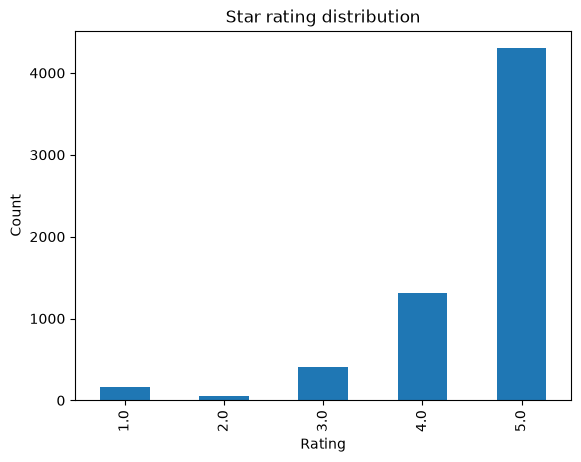

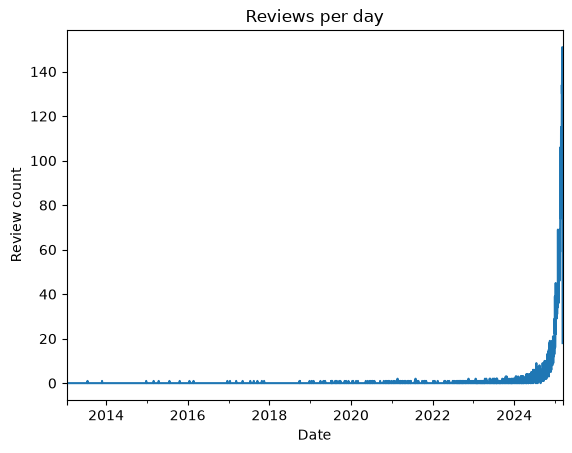

In [11]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar', title='Star rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

df.set_index('at').resample('D').size().plot(title='Reviews per day')
plt.xlabel('Date')
plt.ylabel('Review count')
plt.show()

Number of unique products: 696
count    696.000000
mean       8.954023
std        2.682887
min        1.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       19.000000
Name: count, dtype: float64


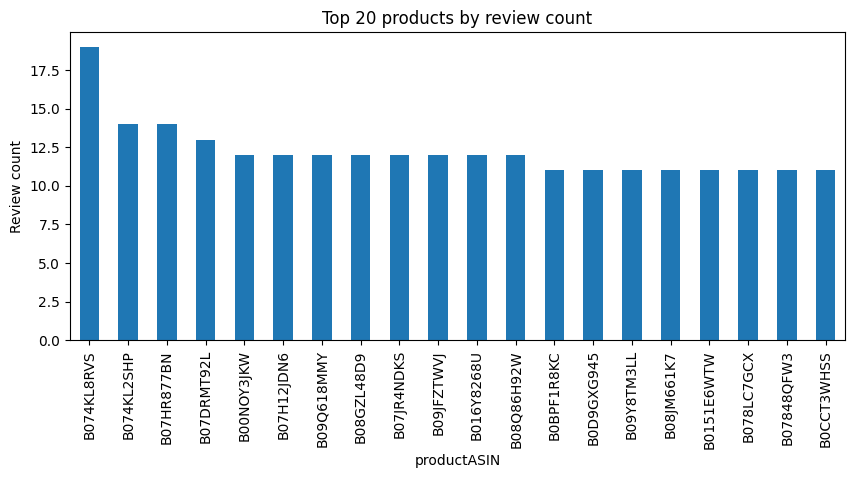

In [ ]:
# Product-level view
reviews_per_product = df['productASIN'].value_counts()
print('Number of unique products:', df['productASIN'].nunique())
print(reviews_per_product.describe())

reviews_per_product.head(20).plot(kind='bar', figsize=(10, 4), title='Top 20 products by review count')
plt.ylabel('Review count')
plt.show()

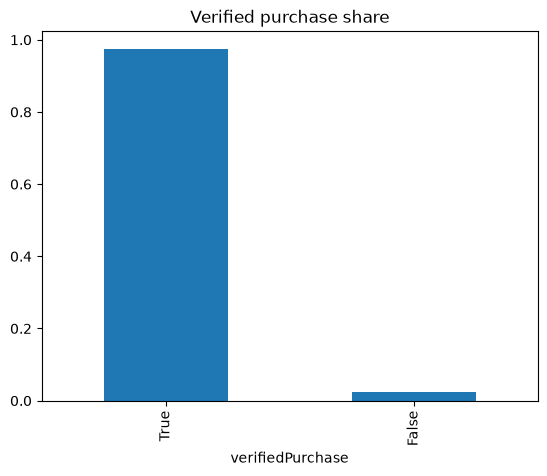

verifiedPurchase
False    4.424837
True     4.532818
Name: rating, dtype: float64


In [12]:
# Verified vs unverified purchase split — a real fake-review signal
df['verifiedPurchase'].value_counts(normalize=True).plot(kind='bar', title='Verified purchase share')
plt.show()

print(df.groupby('verifiedPurchase')['rating'].mean())

***Sentiment score exploration***

count    6232.000000
mean        0.307369
std         0.215248
min        -1.000000
25%         0.171766
50%         0.300000
75%         0.447693
max         1.000000
Name: sentiment_score, dtype: float64


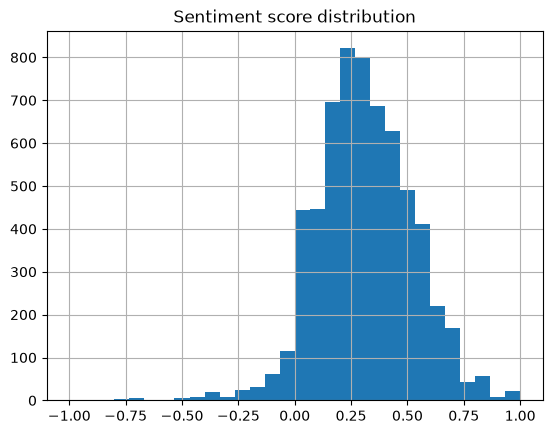

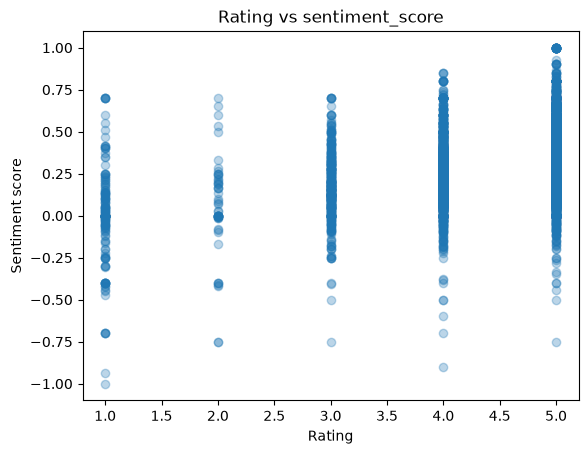

rating
1.0   -0.000914
2.0    0.055709
3.0    0.168947
4.0    0.250913
5.0    0.352338
Name: sentiment_score, dtype: float64


In [ ]:
print(df['sentiment_score'].describe())
df['sentiment_score'].hist(bins=30)
plt.title('Sentiment score distribution')
plt.show()

# Checking the relationship between rating and sentiment score
plt.scatter(df['rating'], df['sentiment_score'], alpha=0.3)
plt.xlabel('Rating')
plt.ylabel('Sentiment score')
plt.title('Rating vs sentiment_score')
plt.show()

print(df.groupby('rating')['sentiment_score'].mean())

## Saving to a new .csv

In [32]:
print(df.dtypes)
print("\nFinal shape:", df.shape)
print("\nColumns kept:", df.columns.tolist())

s.no                         int64
helpfulVoteCount             int64
productASIN                    str
rating                     float64
reviewID                       str
reviewPosition               int64
reviewTitle                    str
reviewURL                      str
verifiedPurchase              bool
sentiment_score            float64
at                  datetime64[us]
content_clean                  str
text_length                  int64
dtype: object

Final shape: (6232, 13)

Columns kept: ['s.no', 'helpfulVoteCount', 'productASIN', 'rating', 'reviewID', 'reviewPosition', 'reviewTitle', 'reviewURL', 'verifiedPurchase', 'sentiment_score', 'at', 'content_clean', 'text_length']


In [33]:
df.to_csv('../data/processed/cleaned_data.csv', index=False)

In [34]:
import os
print(os.path.exists('../data/processed/cleaned_data.csv'))

True
